## Question 1: Regression Analysis & Data Preprocessing – Business and Housing Use Cases

### Scenario

You are working as a data analyst for a **real estate team** that wants to predict house prices using multiple factors.

You must clean, preprocess, analyze, and model the data appropriately.

### Datasets

* **House Prices Dataset (Multiple Linear Regression – Kaggle)**
  [https://www.kaggle.com/datasets/camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

### Tasks

1. Perform **EDA** on datasets. **
2. Apply required **data preprocessing** steps:

   * Handling missing values **
   * Feature encoding (if applicable) **
   * Feature scaling
4. Build a **Multiple Linear Regression** model for the housing dataset.
5. Interpret regression coefficients in real-world terms.
6. Evaluate model using **R²**, **MSE**, and residual analysis.
7. State and verify assumptions of linear regression.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm 
from sklearn.linear_model import LinearRegression


In [105]:
df1 = pd.read_csv("../Dataset/housing.csv")

df1["rooms_per_household"]      = df1["total_rooms"] / df1["households"]
df1["bedrooms_per_room"]        = df1["total_bedrooms"] / df1["total_rooms"]
df1["population_per_household"] = df1["population"] / df1["households"]
df1 = df1.drop(columns=["total_rooms", "total_bedrooms"])
df1.head()

,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


In [106]:
df1.shape

(20640, 11)

In [107]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   population                20640 non-null  float64
 4   households                20640 non-null  float64
 5   median_income             20640 non-null  float64
 6   median_house_value        20640 non-null  float64
 7   ocean_proximity           20640 non-null  str    
 8   rooms_per_household       20640 non-null  float64
 9   bedrooms_per_room         20433 non-null  float64
 10  population_per_household  20640 non-null  float64
dtypes: float64(10), str(1)
memory usage: 1.7 MB


In [108]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
housing_median_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
households,20640.0,499.539680,382.329753,1.000000,280.000000,409.000000,605.000000,6082.000000
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
median_house_value,20640.0,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000
rooms_per_household,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
bedrooms_per_room,20433.0,0.213039,0.057983,0.100000,0.175427,0.203162,0.239821,1.000000
population_per_household,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333


In [109]:
df1.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household']

In [110]:
df1.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64

In [111]:
df1['bedrooms_per_room']= df1.bedrooms_per_room.fillna(df1.bedrooms_per_room.median())
df1.isnull().sum()

longitude                   0
latitude                    0
housing_median_age          0
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64

In [112]:
df1.duplicated().sum()

np.int64(0)

In [113]:
df1["ocean_proximity"].value_counts() #for non numeric data read

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'rooms_per_household'}>,
        <Axes: title={'center': 'bedrooms_per_room'}>],
       [<Axes: title={'center': 'population_per_household'}>, <Axes: >,
        <Axes: >]], dtype=object)

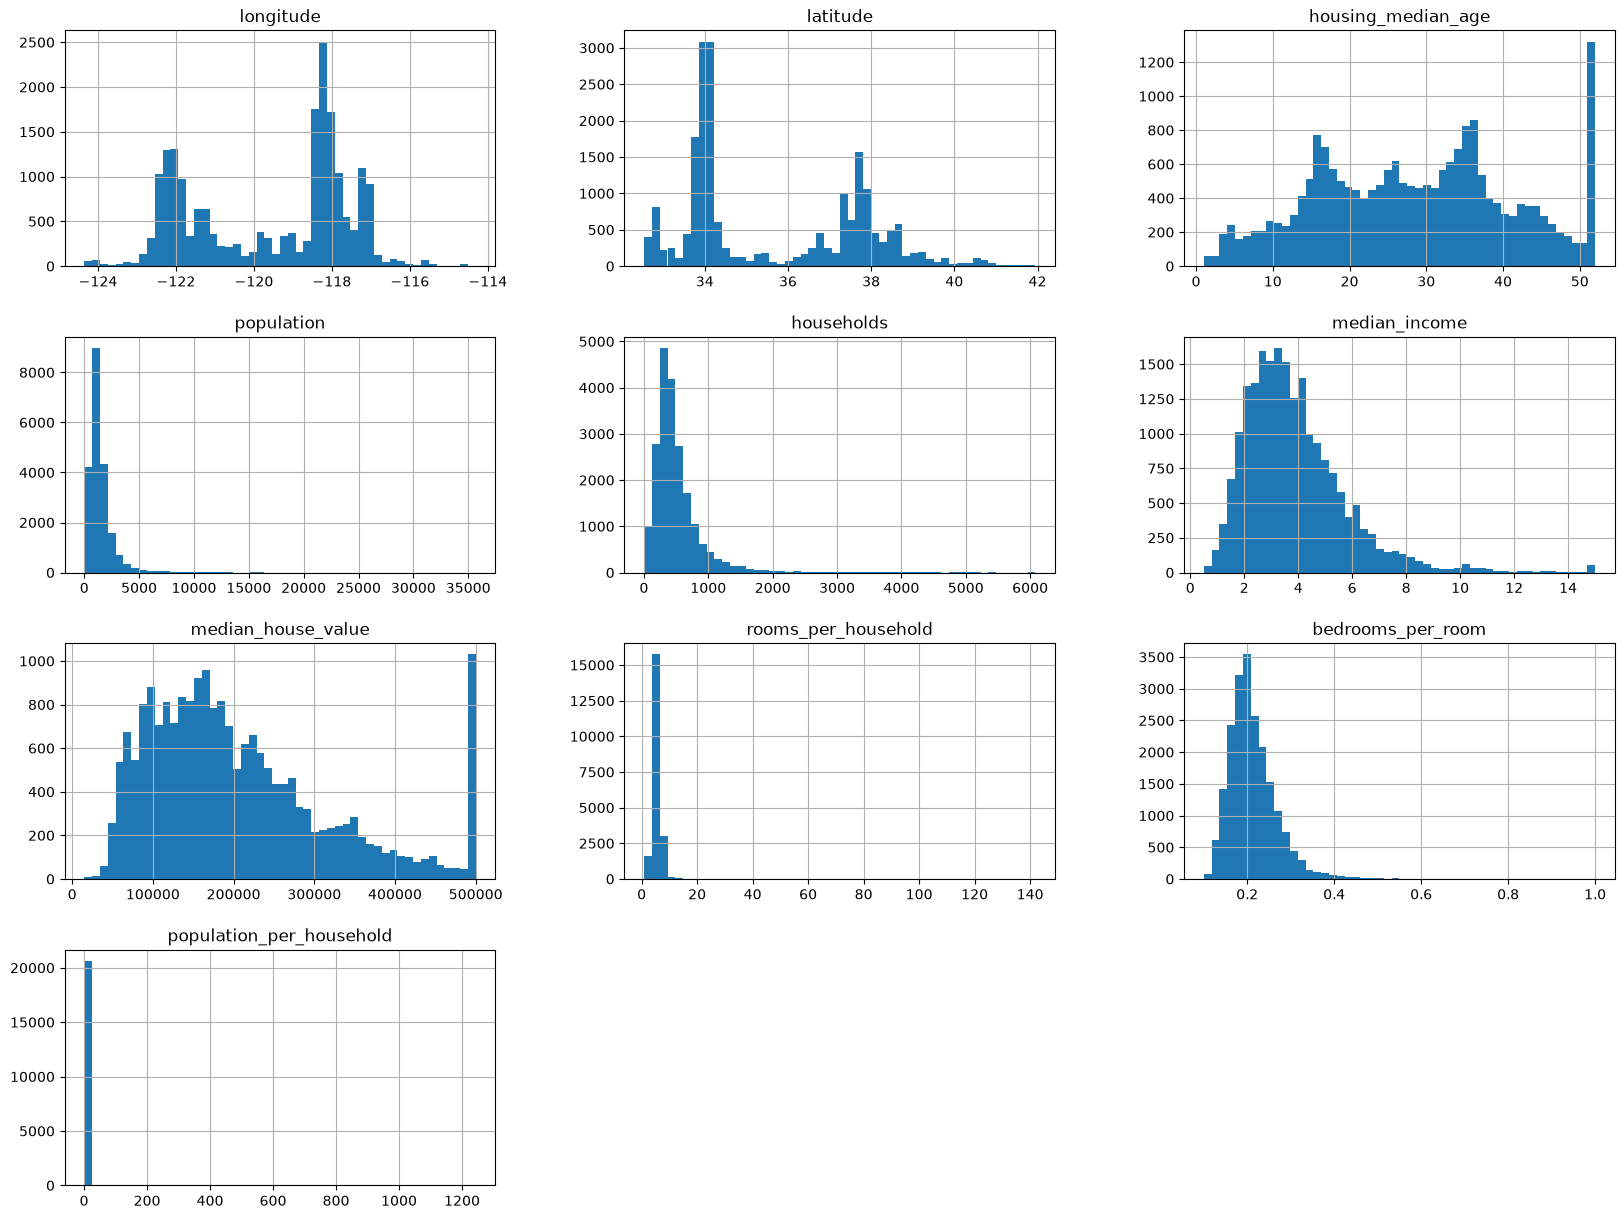

In [114]:
df1.hist(bins=50, figsize=(20,15))

### what alpha does:
Gives us a more precise idea about which area is densely packed with houses. Alpha means transparency of the plots. without alpha, each plot would be weighted the same and you wouldnt have any idea regarding the density.

Text(0.5, 1.0, 'Scatter Plot of California')

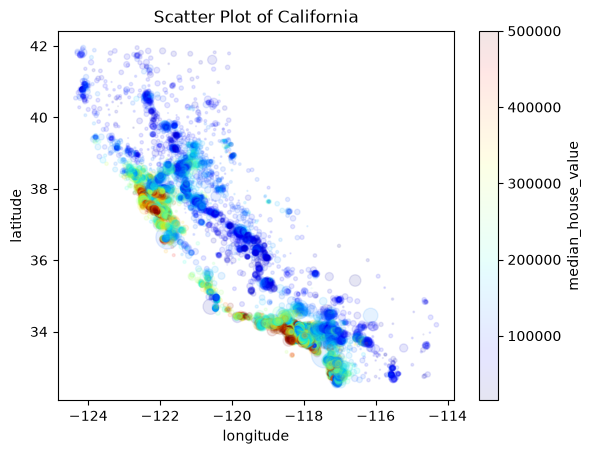

In [115]:
df1.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1, 
         s=df1["population"]/100,
         c="median_house_value",
         cmap=plt.get_cmap("jet")
         )
plt.title("Scatter Plot of California")

## Observation from above:
1. the s value dictates the  scatter plot size vary based on the number of observed counts; higher the count, larger the dot
2. c dictates the color be varied based on the median, where cmap "jet" gives the heatmap kind of color. Here, blue tends to be lower priced while red higher
3. Observation shows that, the area in the bay have houses that are priced higher while the inland areas have fewer, cheaper blocks

In [116]:
corr_matrix= df1.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
housing_median_age          0.105623
households                  0.065843
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.254632
Name: median_house_value, dtype: float64

In [117]:
#One-Hot Encoding
dummies= pd.get_dummies(df1.ocean_proximity)
dummies= dummies.astype(int) # making 0s and 1s instead of T/F
housing_dummies= pd.concat([df1, dummies], axis="columns")
housing_dummies.head()


,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,0,0,0,1,0
1,-122.22,37.86,21.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,0,0,0,1,0
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,0,0,0,1,0
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,0,0,0,1,0
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,0,0,0,1,0


We now drop some variables that are redundant (ocean proximity) or cause multi colinearity issues (Island)

In [118]:
housing_cleaned= housing_dummies.drop(['ocean_proximity', 'ISLAND'], axis= 'columns')
housing_cleaned.head()

,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,0,0,1,0
1,-122.22,37.86,21.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,0,0,1,0
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,0,0,1,0
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,0,0,1,0
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,0,0,1,0


In [119]:
X= housing_cleaned.drop(columns=["median_house_value"]) #removing median house value as the house price is what we're predicting
X.head()

y=housing_cleaned["median_house_value"]
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [120]:
#Split train test
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=2003) #x= featured, y= labelled, test size 20%

In [121]:
num_cols= ['longitude',
 'latitude',
 'housing_median_age',
 'population',
 'households',
 'median_income',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household']

scaler= StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols]  = scaler.transform(X_test[num_cols])

In [122]:

OLS = LinearRegression() #just to make it easier to type instead of LinearRegression

OLS.fit(X_train, y_train) #x,y split because all the columns in x is what causes change in y, the median house price

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ -26932.56, -25773.96, 1060. ,...,-170157.77,-137259.37,-131243.78]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['longitude','latitude','housing_median_age',...,'INLAND','NEAR BAY', 'NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.22e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [123]:
print ("Intercept is "+str(OLS.intercept_)) #intercept and coefficients of the OLS model

print ("The set of coefficients are "+str(OLS.coef_))

print("The r-squared value is "+ str(OLS.score(X_train, y_train)))

Intercept is -2220296.766235792
The set of coefficients are [-2.69325634e+04 -2.57739560e+04  1.05999710e+03 -3.94398552e+01
  1.30246589e+02  4.10535132e+04  3.09140248e+03  2.64498269e+05
  6.40376149e+01 -1.36014875e+05 -1.70157770e+05 -1.37259368e+05
 -1.31243779e+05]
The r-squared value is 0.6517998087015466


In [124]:
#predicitng with OLS

y_pred= OLS.predict(X_test) #basically the y will contain the predicted value based on the X_test
performance= pd.DataFrame({'PREDICTION': y_pred, 'ACTUAL VALUES':y_test}) #check how well the performance is 
performance['ERROR']= performance['ACTUAL VALUES']-performance['PREDICTION'] #residual= error here
performance.head()

,PREDICTION,ACTUAL VALUES,ERROR
14572,230502.149075,212000.0,-18502.149075
94,194533.597874,179200.0,-15333.597874
4408,194238.347247,150000.0,-44238.347247
10237,221666.866032,176300.0,-45366.866032
11376,241737.148864,152100.0,-89637.148864


In [125]:
#preparing data for plotting

performance.reset_index(drop=True, inplace= True) #inplace turns the random sampled index value into a new index
performance.reset_index( inplace= True)
performance.head()

,index,PREDICTION,ACTUAL VALUES,ERROR
0,0,230502.149075,212000.0,-18502.149075
1,1,194533.597874,179200.0,-15333.597874
2,2,194238.347247,150000.0,-44238.347247
3,3,221666.866032,176300.0,-45366.866032
4,4,241737.148864,152100.0,-89637.148864


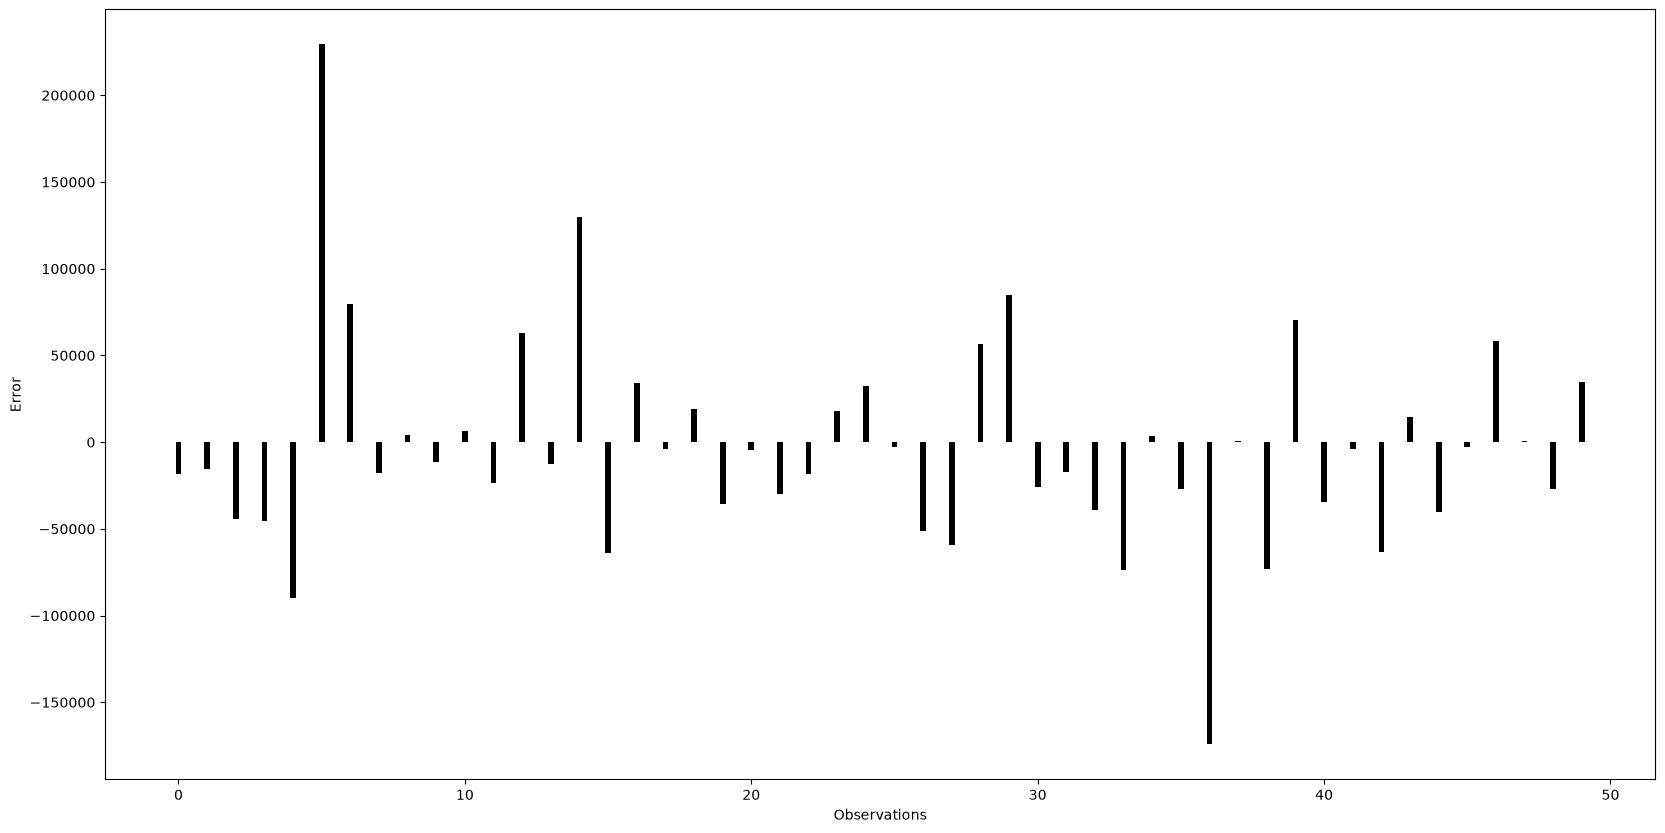

In [126]:
#plotting the error

fig = plt.figure(figsize=(20,10))
plt.bar('index', 'ERROR', data= performance[:50], color= 'black', width=0.2) # [:50] show the plot of the first 50 observations, width is the width of the bar
plt.xlabel("Observations")
plt.ylabel("Error")
plt.show()

In [127]:
# %pip install statsmodels

X_train= sm.add_constant(X_train) #step needed if you want your statsmodel result to be same as the linearregression model. just makes the data more readable with this
better_ols= sm.OLS(y_train, X_train).fit()
better_ols.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     2376.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:22:15   Log-Likelihood:            -2.0714e+05
No. Observations:               16512   AIC:                         4.143e+05
Df Residuals:                   16498   BIC:                         4.144e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                     -2.22e+06   1.04e+05    -21.404      0.000   -2.42e+06   -2.02e+06
longitude                -2.693e+04   1124.204    -23.957      0.000   -2.91e+04   -2.47e+04
latitude                 -2.577e+04   1109.625    -23.228      0.000   -2.79e+04   -2.36e+04
housing_median_age        1059.9971     48.141     22.019      0.000     965.636    1154.358
population                 -39.4399      1.156    -34.107      0.000     -41.706     -37.173
households                 130.2466      3.483     37.392      0.000     123.419     137.074
median_income             4.105e+04    397.420    103.300      0.000    4.03e+04    4.18e+04
rooms_per_household       3091.4025    238.630     12.955      0.000    2623.663    3559.142
bedrooms_per_room         2.645e+05   1.27e+04     20.787      0.000     2.4e+05    2.89e+05
population_per_household    64.0376     47.057      1.361      0.174     -28.200     156.275
<1H OCEAN                 -1.36e+05    3.4e+04     -4.001      0.000   -2.03e+05   -6.94e+04
INLAND                   -1.702e+05   3.41e+04     -4.995      0.000   -2.37e+05   -1.03e+05
NEAR BAY                 -1.373e+05    3.4e+04     -4.033      0.000   -2.04e+05   -7.05e+04
NEAR OCEAN               -1.312e+05    3.4e+04     -3.859      0.000   -1.98e+05   -6.46e+04
==============================================================================
Omnibus:                     4047.850   Durbin-Watson:                   2.021
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            17472.120
Skew:                           1.144   Prob(JB):                         0.00
Kurtosis:                       7.490   Cond. No.                     3.92e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.92e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [128]:
#how to get the MSE for this model

mse= mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
print(f"MSE: {mse:,.0f}  RMSE: {rmse:,.0f}")

MSE: 4,626,798,845  RMSE: 68,021


INTERPRETATION
- Linearity: mostly OK, with some curvature at high prices. Partially satisfied.
- Independence: DW near 2 is fine, but nearby blocks share similar prices
  (spatial correlation), so it is not perfectly independent in reality.
- Multicollinearity: total_rooms, total_bedrooms, population, households and
  longitude / latitude should show high VIF -> VIOLATED. This explains the odd negative coefficients.

POSSIBLE FIXES: drop the capped rows (y == 500001), log-transform the target,
replace the collinear columns with ratios (below)

## Question 2: Classification & Logistic Regression – Employee Attrition or Credit Risk

### Scenario

You are hired by an organization to build a system that predicts a **binary outcome**:

* Whether an **employee will leave** the company, OR
* Whether a **customer will default** on a credit card payment.

### Datasets (Choose ONE)

* **IBM HR Analytics Employee Attrition Dataset**
  [https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

* **Credit Card Default Dataset**
  [https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

### Tasks

1. Justify why **Logistic Regression** is suitable for this problem.
2. Perform full **data preprocessing**:

   * Missing value handling
   * Encoding categorical variables
   * Feature scaling
3. Train a **Logistic Regression** classifier.
4. Evaluate the model using:

   * Confusion Matrix
   * Precision, Recall, F1-score
   * AUC Score
5. Interpret model coefficients using **odds ratios**.
6. Discuss the impact of **class imbalance** and possible solutions.

## Question 3: Hyperparameter Tuning & Model Optimization

### Scenario

After deploying your classification model, stakeholders ask you to **improve performance** without changing the dataset.

You decide to optimize the model using systematic hyperparameter search techniques.

### Dataset

Reuse the dataset from **Question 2**.

### Tasks

1. Explain the difference between **parameters** and **hyperparameters**.
2. Train a **baseline Logistic Regression** model.
3. Apply **GridSearchCV** to tune hyperparameters (`C`, `penalty`, `solver`).
4. Apply **RandomizedSearchCV** and compare results.
5. Compare performance before and after tuning.
6. Discuss trade-offs between **computational cost** and **model performance**.